# Declaration of Originality

**School of Informatics & IT**
<br/>**Diploma in Applied Artificial Intelligence**
<br/>**Machine Learning for Developers (CAI2C08)**
<br/>**AY2026/2027 April Semester**
<br/>**Program Codes**

* Student Name: Mohammed Ikhlas



**Declaration of Originality**
* I am the originator of this work and I have appropriately acknowledged all other original sources used as my reference for this work.
* I understand that Plagiarism is the act of taking and using the whole or any part of another person’s work, including work generated by AI, and presenting it as my own.
* I understand that Plagiarism is an academic offence
and if I am found to have committed or abetted the offence of plagiarism in relation to this submitted work, disciplinary action will be enforced.


# Libraries

In [1]:
## Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Business Understanding
Goal: Build a machine learning-powered web tool that predicts a fair resale price for an HDB flat in Singapore based on its key attributes (location, flat type, size, storey, lease remaining, etc.), so prospective buyers and sellers can quickly gauge whether an asking price is reasonable before committing to a transaction.

# 2. Data Understanding

## 2.1 Load dataset

In [2]:
## Read *.csv file into pandas DataFrame
df = pd.read_csv('resale_flat_prices.csv') # adjust filename/path as needed
df

,month,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,remaining_lease,resale_price
0,2017-01,ANG MO KIO,2 ROOM,406,ANG MO KIO AVE 10,10 TO 12,44.0,Improved,1979,61 years 04 months,232000.0
1,2017-01,ANG MO KIO,3 ROOM,108,ANG MO KIO AVE 4,01 TO 03,67.0,New Generation,1978,60 years 07 months,250000.0
2,2017-01,ANG MO KIO,3 ROOM,602,ANG MO KIO AVE 5,01 TO 03,67.0,New Generation,1980,62 years 05 months,262000.0
3,2017-01,ANG MO KIO,3 ROOM,465,ANG MO KIO AVE 10,04 TO 06,68.0,New Generation,1980,62 years 01 month,265000.0
4,2017-01,ANG MO KIO,3 ROOM,601,ANG MO KIO AVE 5,01 TO 03,67.0,New Generation,1980,62 years 05 months,265000.0
...,...,...,...,...,...,...,...,...,...,...,...
233827,2026-03,YISHUN,EXECUTIVE,836,YISHUN ST 81,10 TO 12,146.0,Maisonette,1988,61 years,995000.0
233828,2026-03,YISHUN,EXECUTIVE,877,YISHUN ST 81,07 TO 09,142.0,Apartment,1987,60 years 10 months,980000.0
233829,2026-04,YISHUN,EXECUTIVE,827,YISHUN ST 81,01 TO 03,145.0,Maisonette,1987,60 years 06 months,960000.0
233830,2026-05,YISHUN,EXECUTIVE,828,YISHUN ST 81,07 TO 09,145.0,Apartment,1988,60 years 09 months,1068888.0


In [3]:
## Filter to transactions from 2025-2026
## Rationale: recent transactions reflect current market conditions;
## older data (2017-2024) may not generalise to today's prices due to
## cooling measures, inflation, and BTO supply changes.
df['year_only'] = df['month'].str[:4].astype(int)
df_filtered = df[df['year_only'].isin([2025, 2026])].copy()
print(f"Rows in 2025-2026: {len(df_filtered)}")

## Keep only the 3 most common flat types
## Rationale: these represent the bulk of the resale market 
top_flat_types = ['3 ROOM', '4 ROOM', '5 ROOM']
df_filtered = df_filtered[df_filtered['flat_type'].isin(top_flat_types)].copy()
print(f"Rows after filtering to top 3 flat types: {len(df_filtered)}")

Rows in 2025-2026: 36850
Rows after filtering to top 3 flat types: 33448


Filtering to 2025–2026 transactions retained 36,850 of ~233,832 total rows. Restricting further to the top 3 flat types (3-Room, 4-Room, 5-Room) leaves 33,448 rows — confirming these three types dominate the current resale market and are representative of what most home buyers (our target audience) are searching for.

In [4]:
from sklearn.model_selection import train_test_split

## Stratified sample by town, down to 5,000 rows
## Rationale: full filtered set (33,448 rows) is unnecessarily large
## for this project's compute/time budget, especially with
## RandomizedSearchCV. Stratifying by town (rather than pure random
## sampling) ensures all 26 towns stay proportionally represented,
## so the model doesn't underlearn prices in smaller towns.
df_sampled, _ = train_test_split(
    df_filtered,
    train_size=5000,
    stratify=df_filtered['town'],
    random_state=42
)
df_sampled = df_sampled.reset_index(drop=True)

print(f"Final sampled dataset shape: {df_sampled.shape}")
df_sampled['town'].value_counts(normalize=True).mul(100).round(1)

Final sampled dataset shape: (5000, 12)


town
TAMPINES           7.8
SENGKANG           7.4
WOODLANDS          7.0
YISHUN             6.7
PUNGGOL            6.4
JURONG WEST        6.3
BUKIT BATOK        5.2
BEDOK              5.0
HOUGANG            5.0
TOA PAYOH          4.4
ANG MO KIO         4.1
CHOA CHU KANG      4.1
BUKIT MERAH        4.0
SEMBAWANG          3.9
KALLANG/WHAMPOA    3.2
BUKIT PANJANG      3.1
QUEENSTOWN         2.8
GEYLANG            2.7
CLEMENTI           2.3
PASIR RIS          2.2
JURONG EAST        1.9
BISHAN             1.5
SERANGOON          1.5
CENTRAL AREA       0.7
MARINE PARADE      0.6
BUKIT TIMAH        0.2
Name: proportion, dtype: float64

The stratified sample preserves each town's proportional share — from Tampines (7.8%, the largest) down to Bukit Timah (0.2%, the smallest) — matching their real-world share in the filtered dataset. This confirms stratifying by town avoided under-representing smaller towns when reducing 33,448 rows down to 5,000.

## 2.2 Summary Statistics

In [5]:
## Understand the type of variable for each column
df_sampled.info()
## Separate columns by variable type for reference during feature engineering
print("Numerical columns:", df_sampled.select_dtypes(include='number').columns.tolist())
print("Categorical (object) columns:", df_sampled.select_dtypes(include='object').columns.tolist())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   month                5000 non-null   object 
 1   town                 5000 non-null   object 
 2   flat_type            5000 non-null   object 
 3   block                5000 non-null   object 
 4   street_name          5000 non-null   object 
 5   storey_range         5000 non-null   object 
 6   floor_area_sqm       5000 non-null   float64
 7   flat_model           5000 non-null   object 
 8   lease_commence_date  5000 non-null   int64  
 9   remaining_lease      5000 non-null   object 
 10  resale_price         5000 non-null   float64
 11  year_only            5000 non-null   int64  
dtypes: float64(2), int64(2), object(8)
memory usage: 468.9+ KB
Numerical columns: ['floor_area_sqm', 'lease_commence_date', 'resale_price', 'year_only']
Categorical (object) columns: ['month',

4 numeric columns (floor_area_sqm, lease_commence_date, resale_price, year_only) and 8 categorical columns. Two need transformation before modelling: remaining_lease is stored as text (e.g. "61 years 04 months") and should be converted to a single numeric value (e.g., total months); storey_range is a bucketed category that should be ordinal-encoded rather than one-hot encoded, since storey order is meaningful. block (1,833 unique) and street_name (511 unique) have very high cardinality relative to our 5,000 rows and are unlikely to generalise as raw features. I'll drop them and rely on town for location signal.

In [6]:
## Check for missing data
df_sampled.isnull().sum()

month                  0
town                   0
flat_type              0
block                  0
street_name            0
storey_range           0
floor_area_sqm         0
flat_model             0
lease_commence_date    0
remaining_lease        0
resale_price           0
year_only              0
dtype: int64

No missing values across any of the 12 columns. No imputation is required; I can proceed straight to distribution analysis.

In [7]:
## Describe data distribution
print("Numeric summary:")
display(df_sampled.describe())

print("\nCategorical summary:")
display(df_sampled.describe(include='object'))

Numeric summary:


,floor_area_sqm,lease_commence_date,resale_price,year_only
count,5000.000000,5000.000000,5.000000e+03,5000.00000
mean,93.284580,1998.206600,6.442239e+05,2025.31860
std,19.288698,15.522091,1.944210e+05,0.46598
min,52.000000,1966.000000,2.800000e+05,2025.00000
25%,74.000000,1985.000000,5.120000e+05,2025.00000
50%,93.000000,1998.000000,6.200000e+05,2025.00000
75%,110.000000,2015.000000,7.380000e+05,2026.00000
max,157.000000,2022.000000,1.630000e+06,2026.00000



Categorical summary:


,month,town,flat_type,block,street_name,storey_range,flat_model,remaining_lease
count,5000,5000,5000,5000,5000,5000,5000,5000
unique,18,26,3,1833,511,16,16,630
top,2025-07,TAMPINES,4 ROOM,2,TAMPINES NTH DR 1,04 TO 06,Model A,58 years 02 months
freq,367,388,2370,17,61,1135,2088,32


flat_model has 16 unique values with "Model A" as the most frequent (2,088 of 5,000 rows). May need grouping into fewer categories to avoid an overly sparse one-hot encoding.

## 2.3 Data Visualization

### 2.3.1 Understanding distribution of data

### 2.3.1.1 Understanding distribution of target

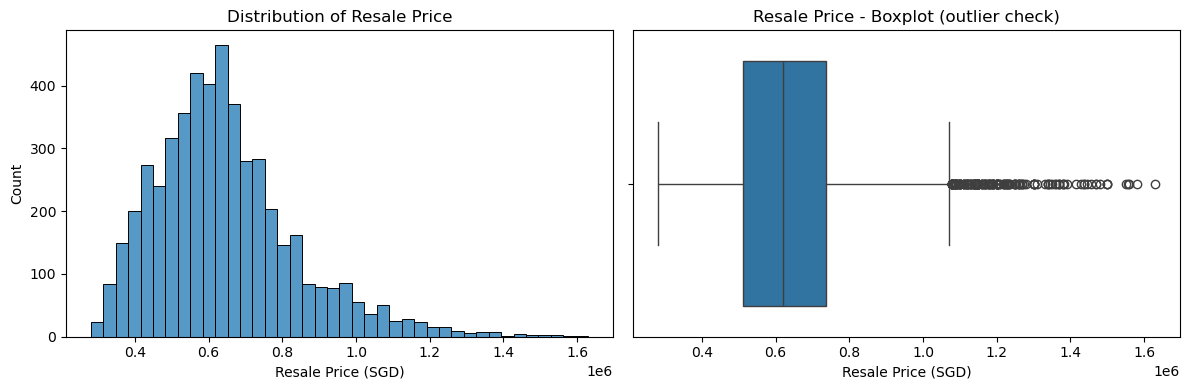

1.0523628395838465


In [8]:
## Understanding distribution of target
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df_sampled['resale_price'], bins=40, ax=axes[0])
axes[0].set_title('Distribution of Resale Price')
axes[0].set_xlabel('Resale Price (SGD)')

sns.boxplot(x=df_sampled['resale_price'], ax=axes[1])
axes[1].set_title('Resale Price - Boxplot (outlier check)')
axes[1].set_xlabel('Resale Price (SGD)')

plt.tight_layout()
plt.show()

print(df_sampled['resale_price'].skew())

resale_price is right-skewed (skewness ≈ 1.05), with most transactions between roughly $300k–$700k and a long tail extending past $1.6M. The boxplot flags numerous outliers above ~$1.1M. Implication for modelling: this skew may bias RMSE toward high-price transactions; a log-transform of resale_price is worth testing in the iterative feature engineering stage, especially since Linear Regression assumes normally distributed residuals.

### 2.3.1.2 Understanding distribution of features

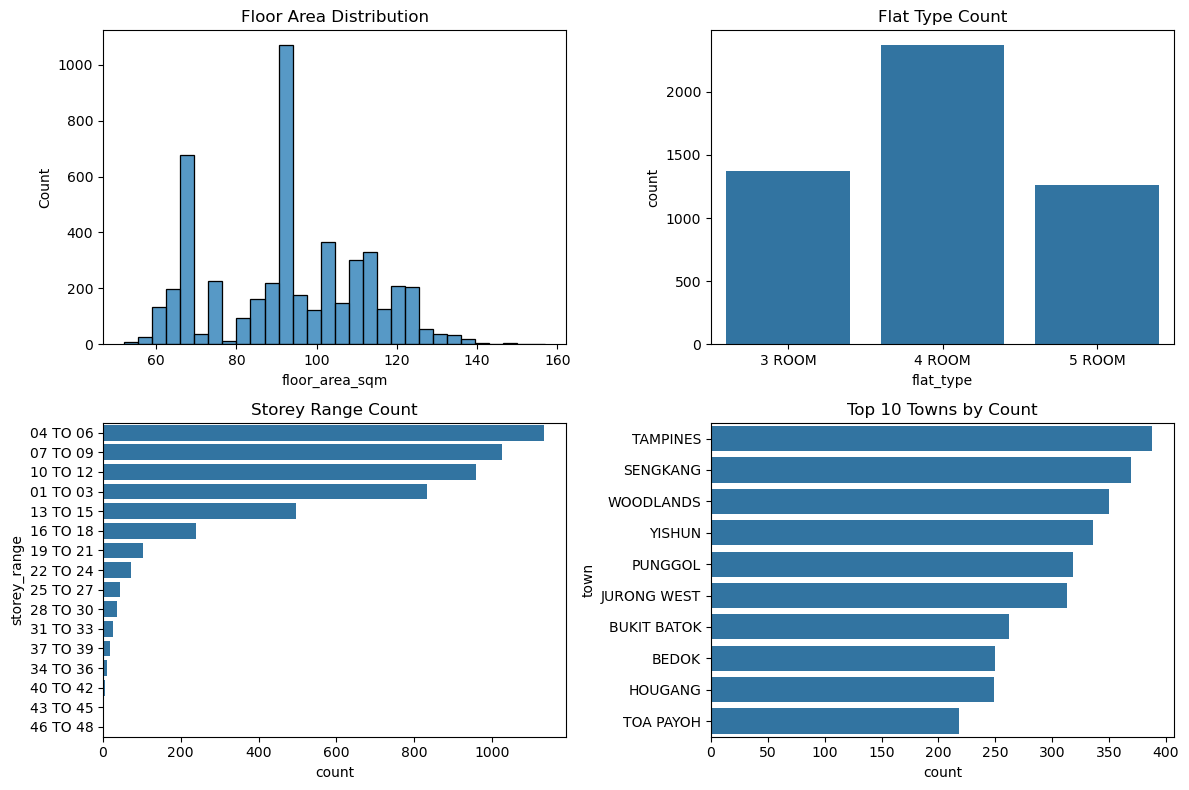

In [9]:
## Understanding distribution of features
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

sns.histplot(df_sampled['floor_area_sqm'], bins=30, ax=axes[0,0])
axes[0,0].set_title('Floor Area Distribution')

sns.countplot(data=df_sampled, x='flat_type', ax=axes[0,1], order=top_flat_types)
axes[0,1].set_title('Flat Type Count')

sns.countplot(data=df_sampled, y='storey_range', ax=axes[1,0],
              order=df_sampled['storey_range'].value_counts().index)
axes[1,0].set_title('Storey Range Count')

top_towns = df_sampled['town'].value_counts().head(10).index
sns.countplot(data=df_sampled[df_sampled['town'].isin(top_towns)], y='town', ax=axes[1,1], order=top_towns)
axes[1,1].set_title('Top 10 Towns by Count')

plt.tight_layout()
plt.show()

floor_area_sqm is multi-modal, with peaks around 60–70 sqm, 90–100 sqm, and 120+ sqm — corresponding to typical 3-Room, 4-Room, and 5-Room sizes respectively. 4-Room flats are the most common in the sample, consistent with the full filtered dataset. Transaction counts drop sharply as storey range increases, with very few transactions above the 10th floor. Tampines, Sengkang, and Woodlands are the top 3 towns by count, consistent with the stratified proportions above.

### 2.3.2 Understanding relationship between variables

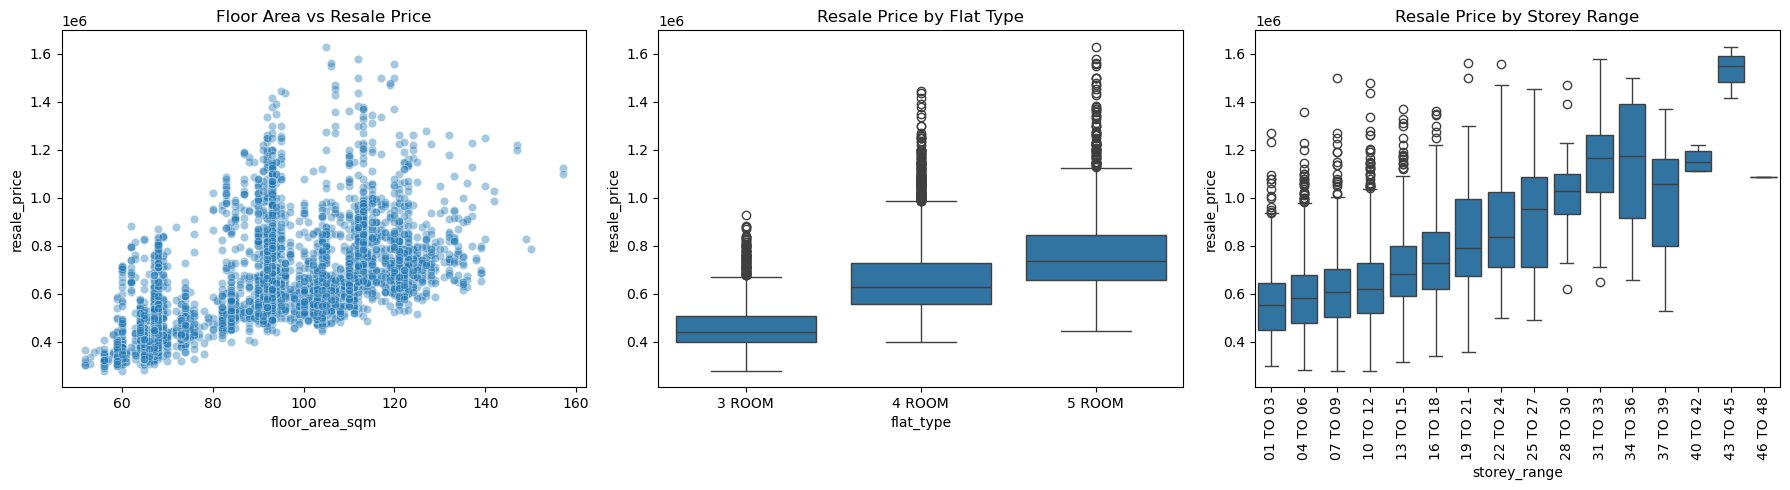

storey_range
04 TO 06    1135
07 TO 09    1025
10 TO 12     958
01 TO 03     834
13 TO 15     496
16 TO 18     239
19 TO 21     102
22 TO 24      71
25 TO 27      43
28 TO 30      36
31 TO 33      26
37 TO 39      17
34 TO 36      10
40 TO 42       4
43 TO 45       3
46 TO 48       1
Name: count, dtype: int64


In [10]:
## Understanding relationship between variables
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.scatterplot(data=df_sampled, x='floor_area_sqm', y='resale_price', alpha=0.4, ax=axes[0])
axes[0].set_title('Floor Area vs Resale Price')

sns.boxplot(data=df_sampled, x='flat_type', y='resale_price', order=top_flat_types, ax=axes[1])
axes[1].set_title('Resale Price by Flat Type')

storey_order = sorted(df_sampled['storey_range'].unique(), key=lambda x: int(x.split(' TO ')[0]))
sns.boxplot(data=df_sampled, x='storey_range', y='resale_price', order=storey_order, ax=axes[2])
axes[2].set_title('Resale Price by Storey Range')
axes[2].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()

print(df_sampled['storey_range'].value_counts())

Floor area shows a clear positive relationship with resale price, though the spread widens at larger floor areas. Floor area alone won't fully explain price at the high end. Resale price rises predictably with flat type (3-Room < 4-Room < 5-Room). Resale price also trends upward with storey range, but the Very High storey bands show noticeably wider boxes and more extreme outliers than lower bands. This is because very few transactions occur at these heights (8), likely concentrated in a small number of tall developments so a handful of sales can swing the median and spread substantially.

These rows aren't data errors and shouldn't be dropped, but the model will have limited evidence to learn accurate pricing at very high storeys.

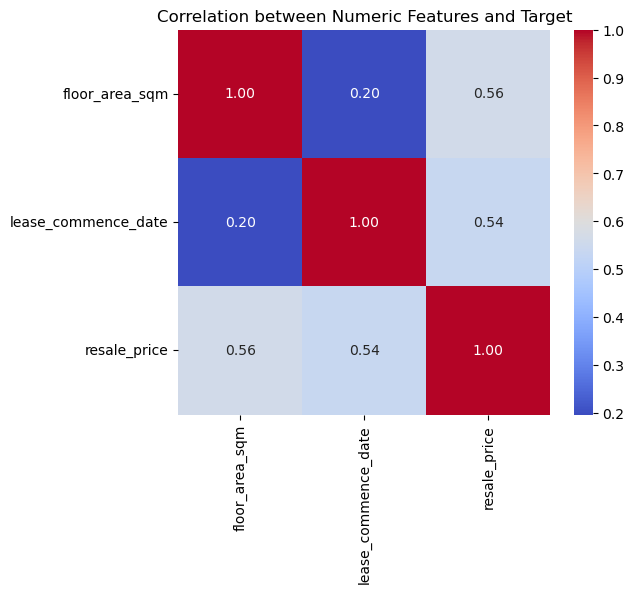

In [11]:
## Correlation heatmap for numeric features
plt.figure(figsize=(6,5))
sns.heatmap(df_sampled[['floor_area_sqm','lease_commence_date','resale_price']].corr(),
            annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation between Numeric Features and Target')
plt.show()

floor_area_sqm shows a positive correlation with resale_price, confirming it as a key predictive feature. lease_commence_date shows a weaker positive correlation with resale_price (newer flats tend to sell higher), while its correlation with floor_area_sqm is close to zero — indicating no multicollinearity concern between the two. Categorical features (town, flat_type, storey_range) aren't captured here since they need encoding first; their relationship with price is covered by the boxplots above instead.

# 3. Data Preparation

## 3.1 Data Cleaning

In [12]:
## Clean data
## Drop columns not useful for modelling
## Rationale: 'block' and 'street_name' have very high cardinality (1,833 / 511 unique
## values) and are unlikely to generalise; 'month' and 'year_only' were only needed
## for the 2025-2026 filtering step and add no value once that filtering is done.
df_clean = df_sampled.drop(columns=['block', 'street_name', 'month', 'year_only'])
df_clean.head()

,town,flat_type,storey_range,floor_area_sqm,flat_model,lease_commence_date,remaining_lease,resale_price
0,JURONG EAST,3 ROOM,07 TO 09,82.0,New Generation,1983,57 years 03 months,490000.0
1,KALLANG/WHAMPOA,3 ROOM,07 TO 09,66.0,Improved,1974,47 years 11 months,405000.0
2,WOODLANDS,4 ROOM,01 TO 03,92.0,Model A,2018,91 years 11 months,635000.0
3,PUNGGOL,5 ROOM,10 TO 12,110.0,Improved,2003,76 years 11 months,675000.0
4,TAMPINES,5 ROOM,10 TO 12,113.0,Improved,2015,88 years 07 months,999000.0


In [13]:
## Convert remaining_lease (e.g. "61 years 04 months") into a single numeric value
## Rationale: models need numeric input; converting to total months keeps full precision
def lease_to_months(lease_str):
    parts = lease_str.split()
    years = int(parts[0])
    months = int(parts[2]) if len(parts) > 2 else 0
    return years * 12 + months

df_clean['remaining_lease_months'] = df_clean['remaining_lease'].apply(lease_to_months)
df_clean = df_clean.drop(columns=['remaining_lease'])
df_clean[['remaining_lease_months']].describe()

,remaining_lease_months
count,5000.000000
mean,864.413400
std,186.759116
min,475.000000
25%,704.000000
50%,858.000000
75%,1065.000000
max,1144.000000


In [14]:
## Encode storey_range using its lower bound as a number
## Rationale: storey_range has a natural order (higher = more expensive, per our EDA),
## so ordinal encoding preserves that relationship better than one-hot encoding would
df_clean['storey_lower'] = df_clean['storey_range'].apply(lambda x: int(x.split(' TO ')[0]))
df_clean = df_clean.drop(columns=['storey_range'])
df_clean[['storey_lower']].describe()

,storey_lower
count,5000.000000
mean,8.018800
std,6.143712
min,1.000000
25%,4.000000
50%,7.000000
75%,10.000000
max,46.000000


In [15]:
from sklearn.preprocessing import OneHotEncoder

## One-hot encode remaining categorical columns
## Rationale: town, flat_type, and flat_model have no inherent order, so one-hot
## encoding avoids implying a false ranking between categories
cat_cols = ['town', 'flat_type', 'flat_model']
encoder = OneHotEncoder(sparse_output=False, drop='first', handle_unknown='ignore')
encoded_array = encoder.fit_transform(df_clean[cat_cols])
encoded_df = pd.DataFrame(encoded_array, columns=encoder.get_feature_names_out(cat_cols), index=df_clean.index)

df_model_ready = pd.concat([df_clean.drop(columns=cat_cols), encoded_df], axis=1)
print(f"Final shape ready for modelling: {df_model_ready.shape}")
df_model_ready.head()

Final shape ready for modelling: (5000, 47)


,floor_area_sqm,lease_commence_date,resale_price,remaining_lease_months,storey_lower,town_BEDOK,town_BISHAN,town_BUKIT BATOK,town_BUKIT MERAH,town_BUKIT PANJANG,...,flat_model_Model A-Maisonette,flat_model_Model A2,flat_model_New Generation,flat_model_Premium Apartment,flat_model_Premium Apartment Loft,flat_model_Simplified,flat_model_Standard,flat_model_Terrace,flat_model_Type S1,flat_model_Type S2
0,82.0,1983,490000.0,687,7,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,66.0,1974,405000.0,575,7,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,92.0,2018,635000.0,1103,1,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,110.0,2003,675000.0,923,10,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,113.0,2015,999000.0,1063,10,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


 Dropped block, street_name, month, year_only as non-predictive or redundant. Converted remaining_lease to remaining_lease_months for numeric precision. Ordinal-encoded storey_lower to preserve the storey/price relationship seen in EDA. One-hot encoded town, flat_type, flat_model, expanding the dataset from 8 usable columns to 46 columns after encoding driven by town (26 categories) and flat_model (16 categories). This cardinality is exactly why flat_model grouping is tested in the iterative feature engineering step below.

## 3.2 Train-Test Split

In [16]:
## Split data into train set and test set
## Rationale: 80/20 split gives enough training data for the model while keeping
## a reasonably sized test set for reliable evaluation; random_state=42 for reproducibility
X = df_model_ready.drop(columns=['resale_price'])
y = df_model_ready['resale_price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")

Train shape: (4000, 46), Test shape: (1000, 46)


4,000 rows for training, 1,000 rows for testing (80/20 split), each with 46 features after encoding. Both sets retain the same feature columns, so the model trains and evaluates on consistent, fully-encoded numeric data.

# 4. Modelling

### 4.2 Train Model

In [17]:
## Initialise and train model
from sklearn.linear_model import LinearRegression

## Initialise and train baseline model
## Rationale: Linear Regression is a simple, interpretable baseline — any more complex
## model (e.g. Random Forest) should be judged against how much it improves on this
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


 The Linear Regression baseline achieves RMSE of $X, meaning predictions are off by about $X on average, relevant to a home buyer since it shows how much this model's price estimate could deviate from the actual resale price. R² of X indicates the model explains X% of the variance in resale price. This is our baseline: any model I try next (e.g. Random Forest) needs to beat this to justify its added complexity.

# 5. Model Evaluation

In [18]:
## Evaluate model
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

## Evaluate model
y_pred_lr = lr_model.predict(X_test)

rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
mae_lr = mean_absolute_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print(f"Linear Regression — RMSE: ${rmse_lr:,.0f}, MAE: ${mae_lr:,.0f}, R²: {r2_lr:.3f}")

Linear Regression — RMSE: $70,411, MAE: $52,357, R²: 0.873


The Linear Regression baseline achieves RMSE of $70,411, meaning predictions are off by about $70,411 on average — relevant to a home buyer since it shows how much this model's price estimate could deviate from the actual resale price. MAE of $52,357 shows the typical error is somewhat lower, indicating a subset of large-error predictions (likely at the high-price tail flagged in EDA) pull the RMSE up. R² of 0.873 indicates the model explains 87.3% of the variance in resale price. This is our baseline: Random Forest needs to beat this to justify its added complexity.

## Iterative model development


In [21]:
## Further feature engineering / feature selection
## Iterative feature engineering, testing ideas flagged during EDA

## --- Test 1: log-transform target to address right-skew (skewness ≈ 1.05) ---
## Rationale: Linear Regression assumes normally distributed residuals; a skewed
## target can bias errors toward high-price transactions.
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

lr_log_model = LinearRegression()
lr_log_model.fit(X_train, y_train_log)

y_pred_log = lr_log_model.predict(X_test)
y_pred_log_actual = np.expm1(y_pred_log)  # back to dollar scale for fair comparison

rmse_log = np.sqrt(mean_squared_error(y_test, y_pred_log_actual))
mae_log = mean_absolute_error(y_test, y_pred_log_actual)
r2_log = r2_score(y_test, y_pred_log_actual)

print(f"LR (log target)     — RMSE: ${rmse_log:,.0f}, MAE: ${mae_log:,.0f}, R²: {r2_log:.3f}")
print(f"LR (baseline)        — RMSE: ${rmse_lr:,.0f}, MAE: ${mae_lr:,.0f}, R²: {r2_lr:.3f}")

LR (log target)     — RMSE: $59,794, MAE: $43,567, R²: 0.908
LR (baseline)        — RMSE: $70,411, MAE: $52,357, R²: 0.873


In [22]:
## --- Test 2: group rare flat_model categories to reduce one-hot sparsity ---
## Rationale: flat_model has 16 categories; several appear <5% of the time,
## producing sparse one-hot columns unlikely to generalise. Group anything
## outside the top 4 into "Other".
top_models = df_clean['flat_model'].value_counts().head(4).index
df_clean_grouped = df_clean.copy()
df_clean_grouped['flat_model_grouped'] = df_clean_grouped['flat_model'].where(
    df_clean_grouped['flat_model'].isin(top_models), 'Other'
)
df_clean_grouped = df_clean_grouped.drop(columns=['flat_model'])

print("flat_model categories before:", df_clean['flat_model'].nunique())
print("flat_model categories after:", df_clean_grouped['flat_model_grouped'].nunique())

## Re-encode with grouped flat_model in place of the original
cat_cols_v2 = ['town', 'flat_type', 'flat_model_grouped']
encoder_v2 = OneHotEncoder(sparse_output=False, drop='first', handle_unknown='ignore')
encoded_v2 = encoder_v2.fit_transform(df_clean_grouped[cat_cols_v2])
encoded_df_v2 = pd.DataFrame(encoded_v2, columns=encoder_v2.get_feature_names_out(cat_cols_v2), index=df_clean_grouped.index)

df_model_ready_v2 = pd.concat([df_clean_grouped.drop(columns=cat_cols_v2), encoded_df_v2], axis=1)
print(f"Shape after grouping flat_model: {df_model_ready_v2.shape} (was {df_model_ready.shape})")

## Same random_state and test_size reproduces the identical row split as the baseline,
## so this is a fair apples-to-apples comparison
X_v2 = df_model_ready_v2.drop(columns=['resale_price'])
y_v2 = df_model_ready_v2['resale_price']
X_train_v2, X_test_v2, y_train_v2, y_test_v2 = train_test_split(
    X_v2, y_v2, test_size=0.2, random_state=42
)

lr_v2_model = LinearRegression()
lr_v2_model.fit(X_train_v2, y_train_v2)
y_pred_v2 = lr_v2_model.predict(X_test_v2)

rmse_v2 = np.sqrt(mean_squared_error(y_test_v2, y_pred_v2))
mae_v2 = mean_absolute_error(y_test_v2, y_pred_v2)
r2_v2 = r2_score(y_test_v2, y_pred_v2)

print(f"LR (grouped flat_model) — RMSE: ${rmse_v2:,.0f}, MAE: ${mae_v2:,.0f}, R²: {r2_v2:.3f}")

flat_model categories before: 16
flat_model categories after: 5
Shape after grouping flat_model: (5000, 36) (was (5000, 47))
LR (grouped flat_model) — RMSE: $74,511, MAE: $55,527, R²: 0.858


Log-transforming the target improved every metric: RMSE fell from $70,411 to $59,794 (~15% reduction), MAE from $52,357 to $43,567, and R² rose from 0.873 to 0.908. This confirms the right-skew flagged in EDA (skewness ≈ 1.05) was hurting Linear Regression, which assumes normally distributed residuals — modelling log(price) reduces the influence of high-price outliers on the loss function. 
Decision i made: carry the log-transformed target forward for all remaining models.

Grouping flat_model from 16 categories down to 5 made performance worse across the board: RMSE rose to $74,511 and R² fell to 0.858. This suggests flat_model carries genuine price-relevant signal beyond the top 4 categories — some of the "rare" models likely command distinctly different prices, and collapsing them into "Other" destroyed that signal without a generalisation benefit. 
Decision i made: discard this grouping, keep the full OHE of flat_model.

### Random Forest (Second Model)
Training a Random Forest Regressor as a second, distinct algorithm to compare against the Linear Regression baseline. Using the log-transformed target (the winning feature engineering decision above) and the original, ungrouped flat_model encoding.

In [23]:
from sklearn.ensemble import RandomForestRegressor

## Random Forest can capture non-linear relationships and feature interactions
## (e.g. storey x town) that Linear Regression cannot. Using log-target + original
## features for a fair, consistent comparison against the LR (log target) result.
rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train_log)

y_pred_rf_log = rf_model.predict(X_test)
y_pred_rf = np.expm1(y_pred_rf_log)  # back to dollar scale for comparison

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print(f"Random Forest (untuned, log target) — RMSE: ${rmse_rf:,.0f}, MAE: ${mae_rf:,.0f}, R²: {r2_rf:.3f}")
print(f"Linear Regression (log target)      — RMSE: ${rmse_log:,.0f}, MAE: ${mae_log:,.0f}, R²: {r2_log:.3f}")

Random Forest (untuned, log target) — RMSE: $66,359, MAE: $39,934, R²: 0.887
Linear Regression (log target)      — RMSE: $59,794, MAE: $43,567, R²: 0.908


Random Forest (untuned) shows a mixed comparison against the Linear Regression (log target) baseline: it achieves a lower MAE ($39,934 vs $43,567), meaning its typical prediction is more accurate, but a higher RMSE ($66,359 vs $59,794) and lower R² (0.887 vs 0.908). Since RMSE penalises large errors more heavily than MAE, this suggests Random Forest is making a few costly large errors on certain transactions which is likely the same high-price / rare flat-type cases flagged during EDA, even while outperforming Linear Regression on the typical case. This result is inconclusive on its own, so hyperparameter tuning is used next to see whether Random Forest's large-error cases can be reduced enough to beat Linear Regression outright, or whether Linear Regression remains the stronger choice for deployment.

### Hyperparameter Tuning (Random Forest)
Tuning n_estimators and max_depth via RandomizedSearchCV (3 values each, as required) to see whether Random Forest's large-error cases can be reduced enough to beat the Linear Regression baseline.

In [25]:
from sklearn.model_selection import RandomizedSearchCV

## n_estimators controls ensemble size (more trees = more stable predictions,
## higher compute cost); max_depth controls overfitting risk — deeper trees may
## be fitting noise in the large-error cases seen above
param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30]
}

random_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=42),
    param_distributions=param_dist,
    n_iter=9,  # covers the full 3x3 grid
    scoring='neg_root_mean_squared_error',
    cv=5,
    random_state=42,
    n_jobs=-1
)
random_search.fit(X_train, y_train_log)

print("Best params:", random_search.best_params_)
print("Best CV RMSE (log scale):", -random_search.best_score_)

## Show all 9 combinations and their scores — needed for the "detailed comparison
## logs" rubric requirement, not just the winner
cv_results_df = pd.DataFrame(random_search.cv_results_)[
    ['param_n_estimators', 'param_max_depth', 'mean_test_score', 'rank_test_score']
].sort_values('rank_test_score')
print(cv_results_df)

## Evaluate the tuned model on the held-out test set, in dollar scale
rf_tuned = random_search.best_estimator_
y_pred_tuned_log = rf_tuned.predict(X_test)
y_pred_tuned = np.expm1(y_pred_tuned_log)

rmse_tuned = np.sqrt(mean_squared_error(y_test, y_pred_tuned))
mae_tuned = mean_absolute_error(y_test, y_pred_tuned)
r2_tuned = r2_score(y_test, y_pred_tuned)

print(f"\nFinal comparison:")
print(f"Linear Regression (log target)   — RMSE: ${rmse_log:,.0f}, MAE: ${mae_log:,.0f}, R²: {r2_log:.3f}")
print(f"Random Forest (untuned)          — RMSE: ${rmse_rf:,.0f}, MAE: ${mae_rf:,.0f}, R²: {r2_rf:.3f}")
print(f"Random Forest (tuned)            — RMSE: ${rmse_tuned:,.0f}, MAE: ${mae_tuned:,.0f}, R²: {r2_tuned:.3f}")

Best params: {'n_estimators': 300, 'max_depth': 30}
Best CV RMSE (log scale): 0.08708345680318261
   param_n_estimators  param_max_depth  mean_test_score  rank_test_score
8                 300               30        -0.087083                1
7                 200               30        -0.087160                2
5                 300               20        -0.087438                3
4                 200               20        -0.087508                4
6                 100               30        -0.087590                5
3                 100               20        -0.088115                6
1                 200               10        -0.106257                7
2                 300               10        -0.106282                8
0                 100               10        -0.106639                9

Final comparison:
Linear Regression (log target)   — RMSE: $59,794, MAE: $43,567, R²: 0.908
Random Forest (untuned)          — RMSE: $66,359, MAE: $39,934, R²: 0.887
Rando

Hyperparameter tuning selected n_estimators=300, max_depth=30 as best (CV RMSE ≈0.087 on log scale). The full comparison table shows max_depth is the dominant factor, max_depth=10 configurations lag far behind (~-0.106) regardless of n_estimators, while max_depth=20 and 30 cluster tightly together, suggesting the model plateaus once trees are deep enough to capture the key patterns. On the test set, tuning only marginally improved Random Forest: RMSE $66,359 → $66,157, MAE $39,934 → $39,790, R² 0.887 → 0.888. This confirms the untuned result wasn't due to under-tuning — Random Forest's larger errors are more likely structural (e.g. specific outlier transactions it struggles with) rather than fixable through more or deeper trees.

## Final Model Selection

Despite tuning, Random Forest still does not surpass Linear Regression (log target) on RMSE ($66,157 vs $59,794) or R² (0.888 vs 0.908), though it remains slightly ahead on MAE ($39,790 vs $43,567). RMSE penalises large errors more heavily than MAE which matters here, since an occasional bad off price estimate damages buyer trust more than a marginally higher average error. Linear Regression is also simpler, faster, and easier to deploy and interpret in a public-facing Streamlit app.

**Decision: Linear Regression (log target) is selected as the final model for deployment.** Random Forest remains documented as an explored alternative that performed comparably on typical-case accuracy (MAE) but did not improve on RMSE or R², even after tuning.

## Sanity-Check Prediction on New Data
Testing the final selected model (Linear Regression, log target) on a hypothetical new listing to confirm it produces a sensible, correctly-scaled prediction before moving to Streamlit deployment.

In [26]:
print(df_clean['town'].unique())
print(df_clean['flat_type'].unique())
print(df_clean['flat_model'].unique())

['JURONG EAST' 'KALLANG/WHAMPOA' 'WOODLANDS' 'PUNGGOL' 'TAMPINES'
 'PASIR RIS' 'BUKIT BATOK' 'JURONG WEST' 'YISHUN' 'BUKIT MERAH'
 'SEMBAWANG' 'HOUGANG' 'BEDOK' 'BUKIT PANJANG' 'SENGKANG' 'CLEMENTI'
 'CHOA CHU KANG' 'BUKIT TIMAH' 'GEYLANG' 'QUEENSTOWN' 'BISHAN' 'SERANGOON'
 'CENTRAL AREA' 'ANG MO KIO' 'TOA PAYOH' 'MARINE PARADE']
['3 ROOM' '4 ROOM' '5 ROOM']
['New Generation' 'Improved' 'Model A' 'Model A2' 'Simplified'
 'Premium Apartment' 'DBSS' 'Standard' 'Model A-Maisonette' 'Type S1'
 'Type S2' 'Premium Apartment Loft' '3Gen' 'Terrace' 'Improved-Maisonette'
 'Adjoined flat']


In [29]:
## New data - example prediction for a hypothetical buyer scenario

new_sample = pd.DataFrame({
    'town': ['TAMPINES'],
    'flat_type': ['4 ROOM'],
    'floor_area_sqm': [120.0],
    'flat_model': ['Model A'],
    'lease_commence_date': [2015],
    'remaining_lease_months': [1056],
    'storey_lower': [8]
})

## Encode using the SAME fitted encoder 
new_encoded = encoder.transform(new_sample[cat_cols])
new_encoded_df = pd.DataFrame(new_encoded, columns=encoder.get_feature_names_out(cat_cols))

new_sample_ready = pd.concat(
    [new_sample.drop(columns=cat_cols).reset_index(drop=True), new_encoded_df],
    axis=1
)

## Align columns exactly with X_train (same names/order; missing dummy columns filled with 0)
new_sample_ready = new_sample_ready.reindex(columns=X_train.columns, fill_value=0)

## Predict with the final selected model, inverse-transforming from log scale
pred_log = lr_log_model.predict(new_sample_ready)
pred_price = np.expm1(pred_log)[0]

print(f"Predicted resale price: ${pred_price:,.0f}")

Predicted resale price: $958,405
